In [2]:
import pandas as pd
import numpy as np
import re
import pickle

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/apple-twitter-sentiment-texts.csv")

df.head()

,text,sentiment
0,Wow. Yall needa step it up @Apple RT @heynyla:...,-1
1,What Happened To Apple Inc? http://t.co/FJEX...,0
2,Thank u @apple I can now compile all of the pi...,1
3,The oddly uplifting story of the Apple co-foun...,0
4,@apple can i exchange my iphone for a differen...,0


In [4]:
print("Shape:", df.shape)

Shape: (1630, 2)


In [5]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['text', 'sentiment'], dtype='object')


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
text         0
sentiment    0
dtype: int64


In [7]:
print("\nDuplicate rows:")
print(df.duplicated().sum())


Duplicate rows:
6


In [8]:
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())


Sentiment distribution:
sentiment
 0    801
-1    686
 1    143
Name: count, dtype: int64


In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1624, 2)


In [10]:
print(df["sentiment"].value_counts().sort_index())

sentiment
-1    683
 0    798
 1    143
Name: count, dtype: int64


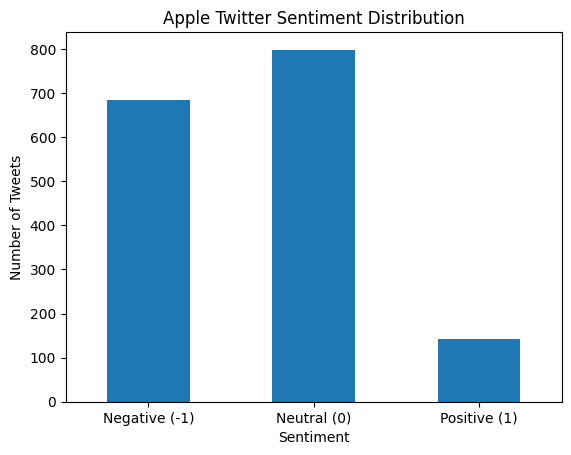

In [11]:
df["sentiment"].value_counts().sort_index().plot(kind="bar")

plt.title("Apple Twitter Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(
    [0, 1, 2],
    ["Negative (-1)", "Neutral (0)", "Positive (1)"],
    rotation=0
)

plt.show()

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # Remove URLs
    text = re.sub(r"@\w+", "", text)             # Remove mentions
    text = re.sub(r"#\w+", "", text)             # Remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # Remove special characters/numbers
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())

                                                text  \
0  Wow. Yall needa step it up @Apple RT @heynyla:...   
1  What Happened To Apple Inc?   http://t.co/FJEX...   
2  Thank u @apple I can now compile all of the pi...   
3  The oddly uplifting story of the Apple co-foun...   
4  @apple can i exchange my iphone for a differen...   

                                          clean_text  
0  wow yall needa step it up rt music and snapcha...  
1                         what happened to apple inc  
2  thank u i can now compile all of the pics that...  
3  the oddly uplifting story of the apple cofound...  
4  can i exchange my iphone for a different color...  


In [14]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

print(df["tokens"].head())

0    [wow, yall, needa, step, it, up, rt, music, an...
1                     [what, happened, to, apple, inc]
2    [thank, u, i, can, now, compile, all, of, the,...
3    [the, oddly, uplifting, story, of, the, apple,...
4    [can, i, exchange, my, iphone, for, a, differe...
Name: tokens, dtype: object


In [15]:
from gensim.models import Word2Vec

word2vec_model = Word2Vec(
    sentences=df["tokens"],
    vector_size=200,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("Word2Vec training completed")
print("Vocabulary size:", len(word2vec_model.wv))

Word2Vec training completed
Vocabulary size: 3463


In [16]:
def get_sentence_vector(tokens):
    vectors = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]

    if len(vectors) == 0:
        return np.zeros(200)

    return np.mean(vectors, axis=0)

X = np.array(df["tokens"].apply(get_sentence_vector).tolist())

print("Feature shape:", X.shape)

Feature shape: (1624, 200)


In [17]:
y = df["sentiment"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sentiment labels:", np.unique(y))

X shape: (1624, 200)
y shape: (1624,)
Sentiment labels: [-1  0  1]


In [18]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original labels:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Original labels: [-1  0  1]
Encoded labels: [0 1 2]


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1299, 200)
X_test shape: (325, 200)
y_train shape: (1299,)
y_test shape: (325,)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (1299, 200)
Scaled X_test shape: (325, 200)


In [21]:
model = keras.Sequential([
    layers.Input(shape=(200,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,179 (133.51 KB)

 Trainable params: 34,179 (133.51 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5438 - loss: 1.0440 - val_accuracy: 0.7038 - val_loss: 0.8618
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6468 - loss: 0.9213 - val_accuracy: 0.7038 - val_loss: 0.7681
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6699 - loss: 0.8406 - val_accuracy: 0.7154 - val_loss: 0.7440
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6987 - loss: 0.8039 - val_accuracy: 0.7038 - val_loss: 0.7159
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7161 - loss: 0.7758 - val_accuracy: 0.7038 - val_loss: 0.7192
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6891 - loss: 0.7655 - val_accuracy: 0.7077 - val_loss: 0.7198
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7247 - loss: 0.7546 - val_accuracy: 0.7154 - val_loss: 0.7160
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7218 - loss: 0.7386 - val_accuracy: 0.7231 - val_loss:

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.7506263256072998
Test Accuracy: 0.6738461256027222


In [24]:
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.67      0.72      0.69       137
     Neutral       0.68      0.75      0.71       160
    Positive       0.00      0.00      0.00        28

    accuracy                           0.67       325
   macro avg       0.45      0.49      0.47       325
weighted avg       0.62      0.67      0.64       325



c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 99  38   0]
 [ 40 120   0]
 [  9  19   0]]


In [26]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training class distribution:
0    546
1    638
2    115
Name: count, dtype: int64

Testing class distribution:
0    137
1    160
2     28
Name: count, dtype: int64


In [27]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

Class weights:
{0: 0.793040293040293, 1: 0.6786833855799373, 2: 3.765217391304348}


In [28]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6901 - loss: 0.9381 - val_accuracy: 0.7192 - val_loss: 0.7254
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6670 - loss: 0.9027 - val_accuracy: 0.6846 - val_loss: 0.7958
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6882 - loss: 0.9096 - val_accuracy: 0.4846 - val_loss: 0.9818
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5938 - loss: 0.9054 - val_accuracy: 0.6846 - val_loss: 0.8325
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6554 - loss: 0.8841 - val_accuracy: 0.7269 - val_loss: 0.7733
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6891 - loss: 0.8541 - val_accuracy: 0.7154 - val_loss: 0.7665
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6574 - loss: 0.8535 - val_accuracy: 0.6538 - val_loss: 0.8353
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6554 - loss: 0.8512 - val_accuracy: 0.6154 - val_loss:

In [29]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.8588483929634094
Test Accuracy: 0.6430768966674805


In [30]:
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted class distribution:")
print(pd.Series(y_pred).value_counts().sort_index())

Predicted class distribution:
0    123
1    153
2     49
Name: count, dtype: int64


In [31]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.72      0.64      0.68       137
     Neutral       0.73      0.69      0.71       160
    Positive       0.20      0.36      0.26        28

    accuracy                           0.64       325
   macro avg       0.55      0.56      0.55       325
weighted avg       0.68      0.64      0.66       325



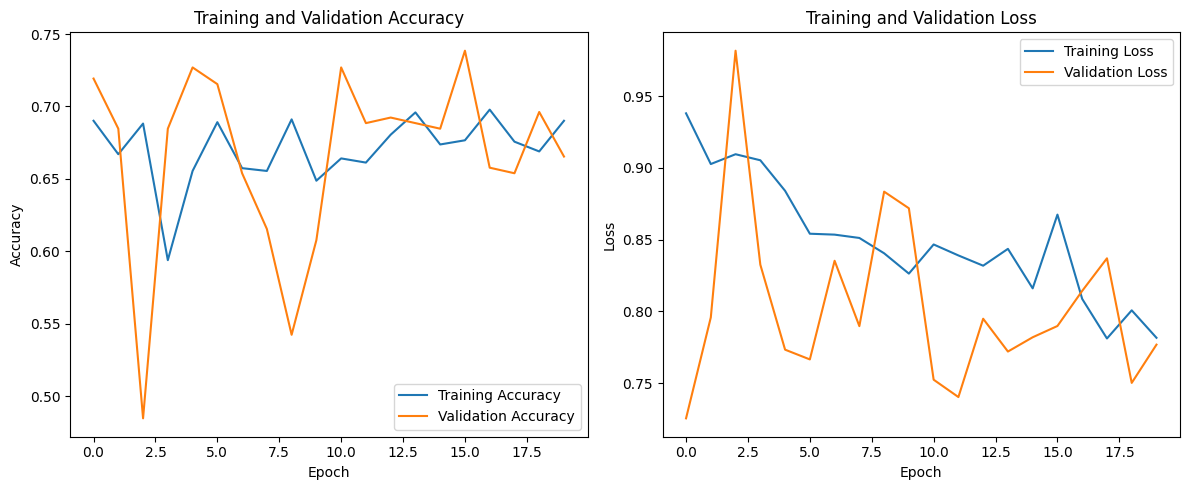

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
cm_weighted = confusion_matrix(y_test, y_pred)

print("Weighted Model Confusion Matrix:")
print(cm_weighted)

Weighted Model Confusion Matrix:
[[ 88  29  20]
 [ 30 111  19]
 [  5  13  10]]


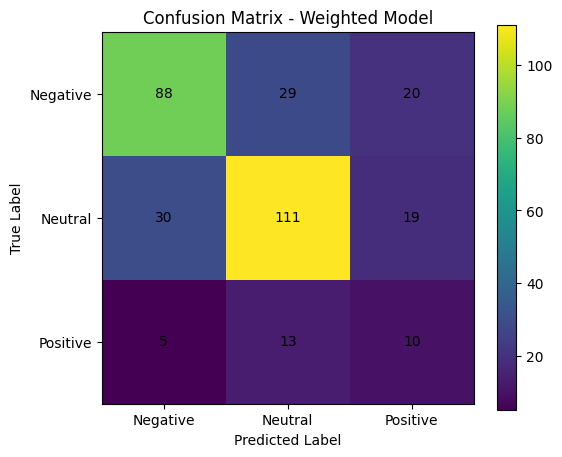

In [34]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_weighted)

plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.yticks([0, 1, 2], ["Negative", "Neutral", "Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Weighted Model")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm_weighted[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [35]:
import os
import pickle

os.makedirs("models", exist_ok=True)

# Save Word2Vec model
word2vec_model.save("models/word2vec.model")

# Save trained neural network
model.save("models/sentiment_model.keras")

# Save scaler
with open("models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save label encoder
with open("models/label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("All models and preprocessing files saved successfully!")

All models and preprocessing files saved successfully!


In [36]:
import os

print("Files in models folder:")

for file in os.listdir("models"):
    print(file)

Files in models folder:
label_encoder.pkl
scaler.pkl
sentiment_model.keras
word2vec.model
